In [1]:
import pandas as pd

# Load dataset
df = pd.read_excel(r"C:\Users\ss295\Desktop\desktop\Data Science\Intership & Certificates\Tata micro intership\Delinquency_prediction_dataset.xlsx")

print("="*50)
print("1. DATASET SHAPE")
print(df.shape)

print("\n" + "="*50)
print("2. COLUMN NAMES")
print(df.columns.tolist())

print("\n" + "="*50)
print("3. DATA TYPES")
print(df.dtypes)

print("\n" + "="*50)
print("4. MISSING VALUES")
print(df.isnull().sum())

print("\n" + "="*50)
print("5. FIRST 5 ROWS")
print(df.head())

1. DATASET SHAPE
(500, 19)

2. COLUMN NAMES
['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Delinquent_Account', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

3. DATA TYPES
Customer_ID                 str
Age                       int64
Income                  float64
Credit_Score            float64
Credit_Utilization      float64
Missed_Payments           int64
Delinquent_Account        int64
Loan_Balance            float64
Debt_to_Income_Ratio    float64
Employment_Status           str
Account_Tenure            int64
Credit_Card_Type            str
Location                    str
Month_1                     str
Month_2                     str
Month_3                     str
Month_4                     str
Month_5                     str
Month_6                     str
dtype: object

4. MISSING VALUES
Customer_ID

In [2]:
# ==========================================================
# CREDIT DELINQUENCY PREDICTION USING LOGISTIC REGRESSION
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [4]:
# ==========================================================
# 1. LOAD DATASET
# ==========================================================

df = pd.read_excel(
    r"C:\Users\ss295\Desktop\desktop\Data Science\Intership & Certificates\Tata micro intership\Delinquency_prediction_dataset.xlsx"
)

print("Dataset Shape:", df.shape)


Dataset Shape: (500, 19)


In [5]:
# ==========================================================
# 2. DROP CUSTOMER ID
# ==========================================================

df.drop("Customer_ID", axis=1, inplace=True)


In [6]:
# ==========================================================
# 3. DEFINE FEATURES & TARGET
# ==========================================================

X = df.drop("Delinquent_Account", axis=1)
y = df["Delinquent_Account"]

In [7]:
# ==========================================================
# 4. IDENTIFY NUMERICAL & CATEGORICAL COLUMNS
# ==========================================================

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numerical Columns:
['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']

Categorical Columns:
['Employment_Status', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']


C:\Users\ss295\AppData\Local\Temp\ipykernel_16572\3737705441.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [8]:
# ==========================================================
# 5. PREPROCESSING PIPELINES
# ==========================================================

# Numerical Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine Both Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [9]:
# ==========================================================
# 6. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
# ==========================================================
# 7. PREPROCESS TRAINING DATA
# ==========================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training Shape:", X_train_processed.shape)
print("Testing Shape:", X_test_processed.shape)

Training Shape: (400, 33)
Testing Shape: (100, 33)


In [11]:
# ==========================================================
# 8. APPLY SMOTE + TRAIN MODEL
# ==========================================================

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("\nModel Training Completed!")

Before SMOTE:
Delinquent_Account
0    336
1     64
Name: count, dtype: int64

After SMOTE:
Delinquent_Account
0    336
1    336
Name: count, dtype: int64

Model Training Completed!


In [12]:
# ==========================================================
# 9. PREDICTIONS
# ==========================================================

y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:,1]


In [13]:
# ==========================================================
# 10. MODEL EVALUATION
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n================ MODEL PERFORMANCE ================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")


================ MODEL PERFORMANCE ================
Accuracy  : 0.8300
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.4219


In [14]:
# ==========================================================
# 11. CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.99      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.83       100
   macro avg       0.42      0.49      0.45       100
weighted avg       0.70      0.83      0.76       100



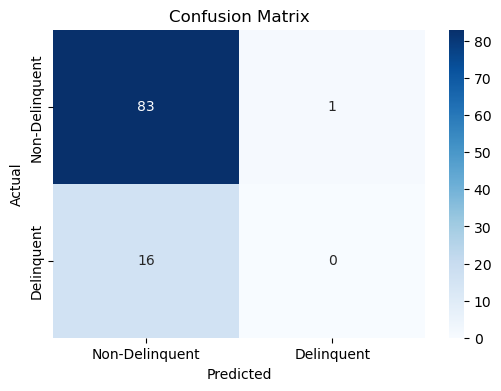

In [15]:
# ==========================================================
# 12. CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Delinquent', 'Delinquent'],
    yticklabels=['Non-Delinquent', 'Delinquent']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

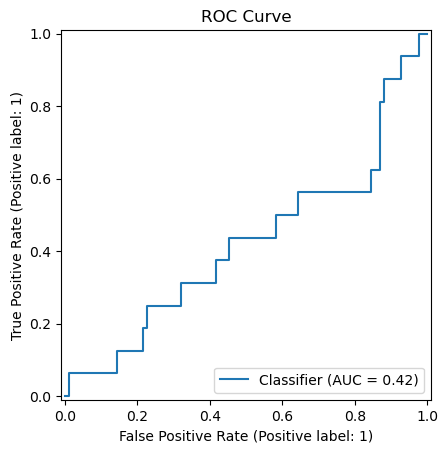

In [16]:
# ==========================================================
# 13. ROC CURVE
# ==========================================================

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")
plt.show()


In [17]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:\n")
print(importance.head(10))


Top 10 Important Features:

                            Feature  Importance
28             cat__Month_4_On-time    0.068646
1                       num__Income    0.056640
3           num__Credit_Utilization    0.053691
8   cat__Employment_Status_Employed    0.047101
30             cat__Month_5_On-time    0.041457
0                          num__Age    0.041391
15   cat__Credit_Card_Type_Standard    0.040590
29              cat__Month_5_Missed    0.039294
7               num__Account_Tenure    0.037604
6         num__Debt_to_Income_Ratio    0.037363


In [18]:
# =======================
# 12. CLASSIFICATION REPORT
# =======================

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))


Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.99      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.83       100
   macro avg       0.42      0.49      0.45       100
weighted avg       0.70      0.83      0.76       100

